## EDA 3. Price Increase Threshold Modeling

#### 1. Overview
- There exists a price threshold beyond which churn risk accelerates non-linearly and substitution threat amplifies that tipping point 
- Price sensitivity differs structurally bt segment (Family vs Individual) and tenure cohort
- External substitution threat (Netflix alternative search intensity) acts as an amplifier that lowers the effective price threshold

#### 2. Research Hypothesis
- **Core Hypothesis**: Churn risk accelerates non-linearly beyond a price threshold, and this threshold is lowered when substitution threat is high
-**Sub Hypothesis**: Individual users reach their price threshold earlier than Family users use to higher per-capita cost burden 

#### 3. Key Inputs from H1 & H2
- H1: Segment X Price tier interaction confirms multiplicative churn risk (Fresh + High = 86.7%)
- H2: Family survivors show structurally lower churn sensitivity across all price tiers
- H3: Post-policy substitution search intensity increased +197% vs 76% for ad-free search --> substitution threat dominates



In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from scipy import stats

In [3]:
# Load data
df = pd.read_csv('../data/processed/cleaned_data.csv')
alt = pd.read_csv('../data/references/alternative_service_free_youtube.csv')

In [4]:
df.shape

(5534, 21)

In [5]:
print(df['Churn'].value_counts())

Churn
No     4063
Yes    1471
Name: count, dtype: int64


### 3.1. Data Preparation
Apply consistent filtering conditions from EDA 01 & 02
- calculated_tenure: reverse-engined from TotalCharges / MonthlyCharges
- Exclude July 2025 outlier (calculated_tenure == 7): confirmed as statistical noise in EDA 01
- Segment definition consistent with EDA 01 tenure cohorts

In [6]:

# Consistenct processing from EDA 01 and EDA 02
df['calculated_tenure'] = (df['TotalCharges'] / df['MonthlyCharges']).round().fillna(0).astype(int)

# Exclude July 2025 outlier (Validated EDA 01)
baseline = df[df['calculated_tenure'] !=7]

# Tenure segments (consistent with EDA 01)
def categorize_tenure(t):
    if t >= 5: return 'Pre-Inflection (5mo+)'   # Before Sep 2025
    elif t >= 3: return 'Inflection (3-5mo)'    # Sep-Oct 2025 - Policy shock period
    else: return 'Fresh (<3mo)'                 # After Nov 2025

df['Segment'] = df['calculated_tenure'].apply(categorize_tenure)

# Price tier: qcut (equal size, consistent with EDA 01)
# Low: $18~$50 / Medium: $50~$84 / High: $84~$118
df['PriceTier'] = pd.qcut(df['MonthlyCharges'], q=3, labels=['Low', 'Medium', 'High'])

# Family vs Individual (consistent with EDA 02)
df['is_family'] = (df['Partner'] == 'Yes' )| (df['Dependents'] == 'Yes')
df['segment_type'] = df['is_family'].map({True: 'Family', False: 'Individual'})

print(f"Segment distribution:\n{df['Segment'].value_counts()}")
print(f"\nFamily vs Individual:\n{df['segment_type'].value_counts()}")

Segment distribution:
Segment
Pre-Inflection (5mo+)    4598
Fresh (<3mo)              639
Inflection (3-5mo)        297
Name: count, dtype: int64

Family vs Individual:
segment_type
Family        2964
Individual    2570
Name: count, dtype: int64


### 3.2. Price threshold Analyst

#### 3.2.1. Baseline: Natural Churn Rate
- Overall churn rate without price increase context
- Family vs Individual natural churn baseline

In [7]:
# Natural Churn Rate baseline (Full dataset, July excluded)
total = len(df)
churned = (df['Churn'] == 'Yes').sum()
natural_churn = churned / total * 100
print(f"Total Customers: {total}")
print(f"Churned Customers: {churned}")
print(f"Overall Churn Rate: {natural_churn:.2f}%")

# family_natural = df[df['is_family']]['Churn'].value_counts(normalize=True)['Yes'] * 100 --> if no Yes, this will error out
family_churn = df[df['is_family']]['Churn'].value_counts(normalize=True).get('Yes', 0) * 100    # if no Yes, default to 0%
individual_churn = df[~df['is_family']]['Churn'].value_counts(normalize=True).get('Yes', 0) * 100

print(f"Family Churn Rate: {family_churn:.2f}%")
print(f"Individual Churn Rate: {individual_churn:.2f}%")

Total Customers: 5534
Churned Customers: 1471
Overall Churn Rate: 26.58%
Family Churn Rate: 20.14%
Individual Churn Rate: 34.01%


#### 3.2.2. Churn Rate by Segment X Proce Tier X Family/Individual
- Extends EDA 01 analysis by adding Family/Individual dimension
- **NOTE**: Inflection(3-5 mo) segment represents policy shock response, not pure price sensitivity
  - These customers joined Sep - Oct 2025, experienced policy change immediately
  - Their churn reflects policy betrayal effect, not price threshold behavior

In [8]:
# Churn Rate by Segment X Price Tier X Family/Individual
churn_rates = df.groupby(['Segment', 'PriceTier', 'segment_type'])['Churn'].value_counts(normalize=True).unstack(fill_value=0)['Yes'] * 100
print("\nChurn Rates by Segment, Price Tier, and Family/Individual:")
print(churn_rates)



Churn Rates by Segment, Price Tier, and Family/Individual:
Segment                PriceTier  segment_type
Fresh (<3mo)           Low        Family          46.052632
                                  Individual      43.265306
                       Medium     Family          63.157895
                                  Individual      75.124378
                       High       Family          83.333333
                                  Individual      88.095238
Inflection (3-5mo)     Low        Family          25.531915
                                  Individual      37.179487
                       Medium     Family          62.857143
                                  Individual      50.588235
                       High       Family          87.500000
                                  Individual      61.111111
Pre-Inflection (5mo+)  Low        Family           6.781751
                                  Individual      11.375212
                       Medium     Family          17.

C:\Users\irene\AppData\Local\Temp\ipykernel_20500\1842204754.py:2: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  churn_rates = df.groupby(['Segment', 'PriceTier', 'segment_type'])['Churn'].value_counts(normalize=True).unstack(fill_value=0)['Yes'] * 100


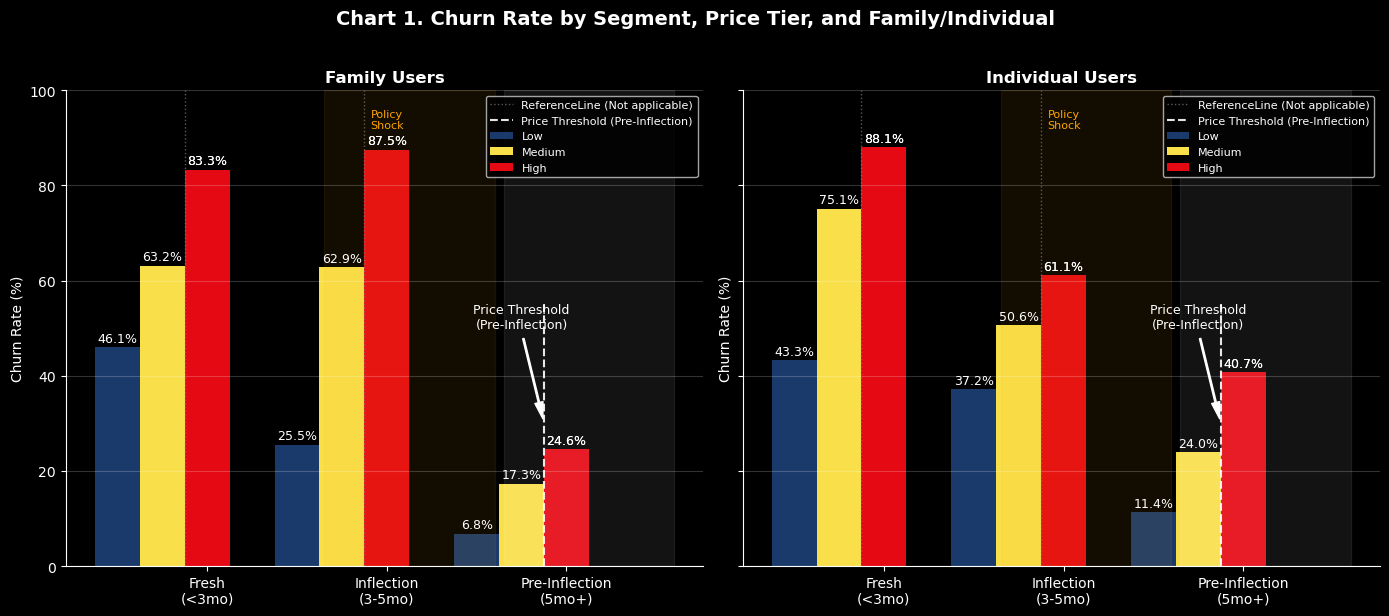

In [9]:
# Visualization - Grouped Bar Chart
plt.style.use('dark_background')
fig, axes = plt.subplots(1, 2, figsize=(14, 6), sharey=True)
fig.suptitle('Chart 1. Churn Rate by Segment, Price Tier, and Family/Individual', fontsize=14, fontweight='bold', y=1.02)
segment_order = ['Fresh (<3mo)', 'Inflection (3-5mo)', 'Pre-Inflection (5mo+)']
price_tiers = ['Low', 'Medium', 'High']
colors = {'Low': '#1a3a6b', 'Medium': '#f9e04b', 'High': '#e50914'}

x = np.arange(len(segment_order))
width = 0.25

for idx, seg_type in enumerate(['Family', 'Individual']):
    for i, price in enumerate(price_tiers):
        vals = [churn_rates.get((seg, price, seg_type), 0) 
                for seg in segment_order]
        bars = axes[idx].bar(x + (i - 1) * width, vals, width, label=price, color=colors[price])
    
        # Value labels on bars
        for bar in bars:
            height = bar.get_height()
            axes[idx].text(bar.get_x() + bar.get_width() / 2, height + 0.5, f'{height:.1f}%', 
                           ha='center', va='bottom', fontsize=9, color='white')

    # Value labels on bars
    for bar in bars:
        height = bar.get_height()
        axes[idx].text(bar.get_x() + bar.get_width() / 2, height + 0.5, f'{height:.1f}%', 
                       ha='center', va='bottom', fontsize=9, color='white')
        
    # Threshold and Reference Lines
    for seg_idx in range(3):
        threshold_x = x[seg_idx] + 0.5 * width   # Position threshold line between Medium and High

        if seg_idx ==2:  # Pre-Inflection segment
            axes[idx].plot([threshold_x, threshold_x], [0, 55], color='white', linestyle='--', linewidth=1.5, alpha=0.9,label='Price Threshold (Pre-Inflection)')

            # Annotation on Medium bar with arrow pointing --> to threshold line
            text_x = threshold_x - 0.5 * width
            axes[idx].annotate('Price Threshold\n(Pre-Inflection)', xy=(threshold_x, 30), xytext=(text_x, 50),
                        arrowprops=dict(facecolor='white', shrink=0.05, width=1, headwidth=6), fontsize=9, color='white', ha='center')
        
        else:   # For Fresh and Inflection segments: grey dotted (Reference Only)
            axes[idx].plot([threshold_x, threshold_x], [0, 100], color='grey', linestyle=':', linewidth=1, alpha=0.7, label='ReferenceLine (Not applicable)' if seg_idx==0 else '' )


    # Zone Highlighting
    # Pre-Inflection: Highlight High Price Tier zone (above threshold) with red shade
    axes[idx].axvspan(x[2] - 0.1, x[2] + 3*width + 0.1, alpha=0.08, color='white')

    # Infection zone:policy shock label
    axes[idx].axvspan(x[1] - 0.1, x[1] + 3*width + 0.1, alpha=0.08, color='orange')
    axes[idx].text(x[1] + width, 92, 'Policy\nShock',
            ha='center', color='orange', fontsize=8)
    
    # Axes formatting
    axes[idx].set_title(f"{seg_type} Users", fontsize=12, fontweight='bold')
    axes[idx].set_xticks(x + width)
    axes[idx].set_xticklabels(['Fresh\n(<3mo)', 'Inflection\n(3-5mo)', 'Pre-Inflection\n(5mo+)'], fontsize=10)
    axes[idx].set_ylabel('Churn Rate (%)', fontsize=10)
    axes[idx].set_ylim(0, 100)
    axes[idx].legend(fontsize=8, title_fontsize=9, loc='upper right')
    axes[idx].grid(axis='y', alpha=0.2)
    axes[idx].spines['top'].set_visible(False)
    axes[idx].spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../outputs/eda_03/graph1_grouped_bar.png', dpi=150, bbox_inches='tight')
plt.show()


#### 3.2.3. Price Threshold: Pre-Inflection Segment (Core Analysis)
- Focus-on Pre-Inflection (5 mo+): long-term customers who experienced price increase
- Inflection segment excluded from threshold analysis (policy shock effect, not price sensitivity)
- This is the cleanest signal for price resistance


In [13]:
# Focus on Pre-Inflection Segment: Pure price sensitivity
pre_inflection = df[df['Segment'] == 'Pre-Inflection (5mo+)'].copy()

# Finer price granularity to find exact threshold
bins_fine = [0, 35, 55, 75, 95, 120]
labels_fine = ['0-35', '35-55', '55-75', '75-95', '95-120']
pre_inflection['PriceTierFine'] = pd.cut(pre_inflection['MonthlyCharges'], bins=bins_fine, labels=labels_fine, include_lowest=True)
threshold_result = pre_inflection.groupby('PriceTierFine')['Churn'].value_counts(normalize=True).unstack(fill_value=0)['Yes'] * 100

print("\nPre-Inflection Segment Churn Rates by Finer Price Tiers:")
print(threshold_result)

# Calculate confidence intervals for each price tier
ci_results = {}
for tier in labels_fine:
    tier_data = pre_inflection[pre_inflection['PriceTierFine'] == tier]
    churned = (tier_data['Churn'] == 'Yes').sum()
    total = len(tier_data)
    if total > 0:
        churn_rate = churned / total
        ci_low, ci_upp = stats.binom.interval(0.95, total, churn_rate, loc=0)
        ci_results[tier] = (churn_rate * 100, ci_low / total * 100, ci_upp / total * 100)
    else:
        ci_results[tier] = (0, 0, 0)  # No data for this tier


# Calculate change between tiers
print("\nChurn Rate Changes Between Price Tiers (Pre-Inflection Segment):")
vals = threshold_result.values
for i in range(1, len(vals)):
    change = vals[i] - vals[i-1]
    print(f'  {labels_fine[i-1]} → {labels_fine[i]}: {change:+.1f}%p')



Pre-Inflection Segment Churn Rates by Finer Price Tiers:
PriceTierFine
0-35       5.865922
35-55     16.468254
55-75     17.866324
75-95     28.125000
95-120    31.488934
Name: Yes, dtype: float64

Churn Rate Changes Between Price Tiers (Pre-Inflection Segment):
  0-35 → 35-55: +10.6%p
  35-55 → 55-75: +1.4%p
  55-75 → 75-95: +10.3%p
  75-95 → 95-120: +3.4%p


C:\Users\irene\AppData\Local\Temp\ipykernel_20500\1149534978.py:8: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  threshold_result = pre_inflection.groupby('PriceTierFine')['Churn'].value_counts(normalize=True).unstack(fill_value=0)['Yes'] * 100


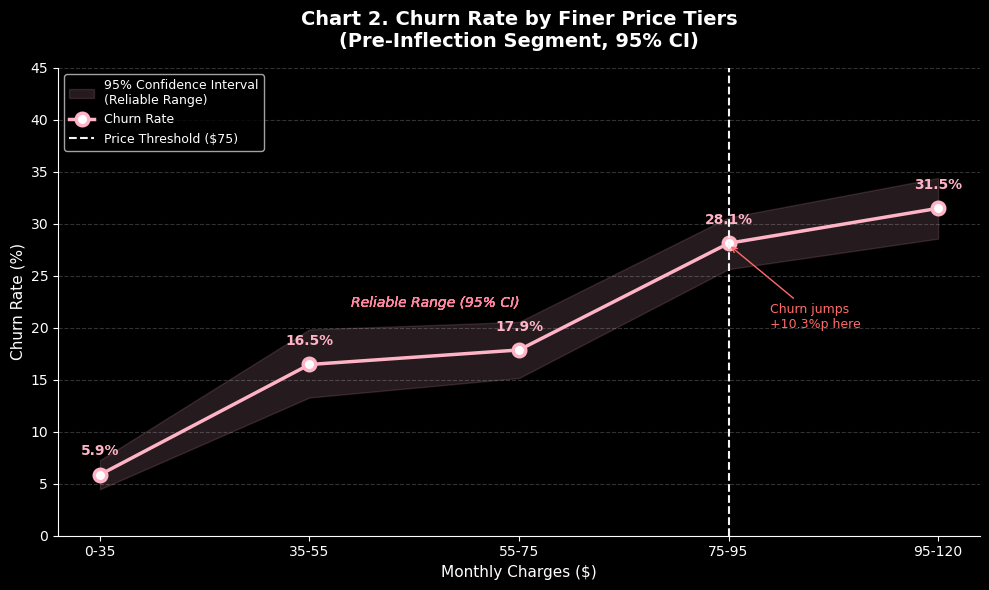

In [25]:
# Visualization - Line Chart with Confidence Intervals
plt.style.use('dark_background')
fig, ax = plt.subplots(figsize=(10, 6))

# Prepare data from ci_results
tiers = list(ci_results.keys())
churn_rates = [ci_results[t][0] for t in tiers]
ci_lows = [ci_results[t][1] for t in tiers]
ci_upps = [ci_results[t][2] for t in tiers]

# Confidence interval band
ax.fill_between(tiers, ci_lows, ci_upps,
                color='#FFB3C6',
                alpha=0.15,
                label='95% Confidence Interval\n(Reliable Range)')

# Main line
ax.plot(tiers, churn_rates,
        marker='o',
        color='#FFB3C6',
        linewidth=2.5,
        markersize=9,
        markerfacecolor='white',
        markeredgewidth=2.5,
        label='Churn Rate')

# Annotate each data point
for i, (tier, rate) in enumerate(zip(tiers, churn_rates)):
    ax.annotate(f'{rate:.1f}%',
                xy=(i, rate),
                xytext=(0, 14),
                textcoords='offset points',
                ha='center',
                fontsize=10,
                fontweight='bold',
                color='#FFB3C6')
    
    ax.annotate('Reliable Range (95% CI)',
            xy=(1, ci_upps[1]),
            xytext=(1.2, 22),
            fontsize=10,
            color='#FF85A1',
            style='italic')

# Price threshold line
ax.axvline(x='75-95',
           color='#F5F5F5',
           linestyle='--',
           linewidth=1.5,
           label='Price Threshold ($75)')

# Threshold annotation
ax.annotate('Churn jumps\n+10.3%p here',
            xy=(3, 28),
            xytext=(3.2, 20),
            fontsize=9,
            color='#FF6B6B',
            arrowprops=dict(arrowstyle='->', color='#FF6B6B'))

# Styling
ax.set_title('Chart 2. Churn Rate by Finer Price Tiers\n(Pre-Inflection Segment, 95% CI)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Monthly Charges ($)', fontsize=11)
ax.set_ylabel('Churn Rate (%)', fontsize=11)
ax.set_ylim(0, 45)  # Tighter y-axis
ax.legend(loc='upper left', fontsize=9)
ax.grid(axis='y', alpha=0.2, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../outputs/eda_03/graph2_line_chart.png', dpi=150, bbox_inches='tight')
plt.show()

#### 3.3. Substitution Threat as Amplifier

##### Search Intensity: Netflix Alternative vs Ad-Free YouTube
- Post-policy substitution search increased + 115% vs +68.3% for ad-free search
- substitution threat grows 1.7x faster than ad-aversion utility
- This amplifies price sensitivity - lowers effective threshold


In [34]:
# Substitution threat analysis: Compare with alternative service (YouTube Free)
# Exclude July outlier

pre_policy = alt[alt['Time'] < '2025-09-01']
post_policy = alt[alt['Time'] >= '2025-09-01']

netflix_pre = pre_policy['netflix alternative'].mean()
netflix_post = post_policy['netflix alternative'].mean()
adfree_pre = pre_policy['ad free youtube'].mean()
adfree_post = post_policy['ad free youtube'].mean()

netflix_change = (netflix_post - netflix_pre) / netflix_pre * 100
adfree_change = (adfree_post - adfree_pre) / adfree_pre * 100

print('*** Substitution Threat Analysis (YouTube Free) ***')
print(f'Netflix Alternative: {netflix_pre:.1f} -> {netflix_post:.1f} ({netflix_change:+.1f}%)')
print(f'Ad-Free YouTube: {adfree_pre:.1f} → {adfree_post:.1f} ({adfree_change:+.1f}%)')
print(f'\nSubstitution grows {netflix_change / adfree_change:.1f} X faster than ad-aversion')
print(f'\n -> Substitution threat dominates as churn amplifier post price increase')


*** Substitution Threat Analysis (YouTube Free) ***
Netflix Alternative: 15.8 -> 34.0 (+115.9%)
Ad-Free YouTube: 31.2 → 52.5 (+68.3%)

Substitution grows 1.7 X faster than ad-aversion

 -> Substitution threat dominates as churn amplifier post price increase


Data after removing July: 24 rows


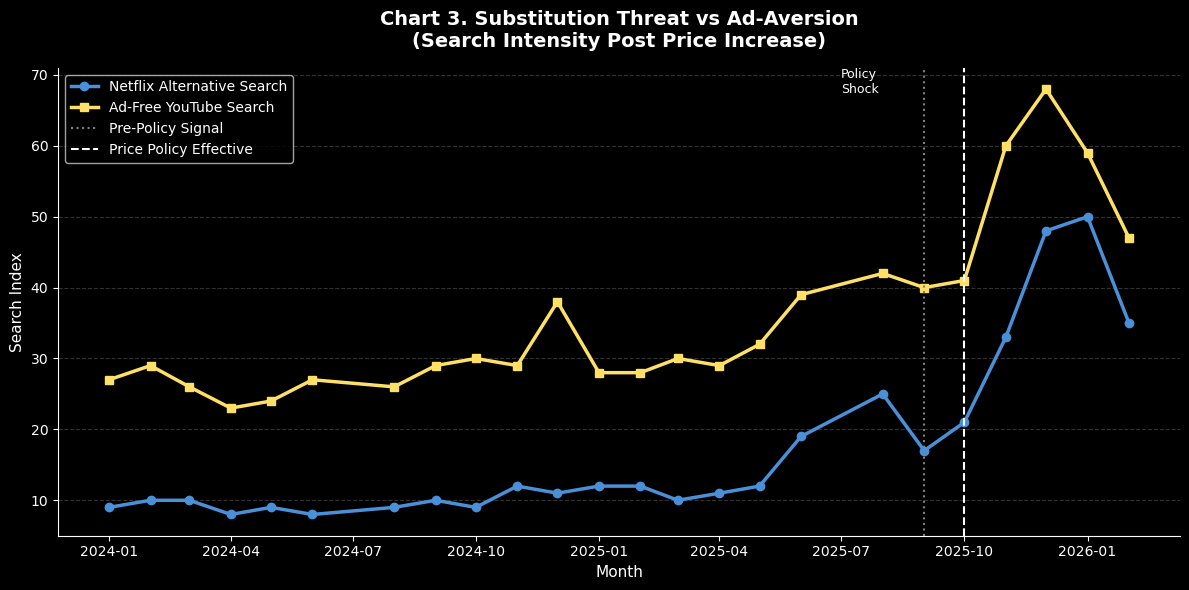

In [41]:
# Convert Time column to datetime
alt['Time'] = pd.to_datetime(alt['Time'])
# Remove July outlier before any processing
alt = alt[alt['Time'].dt.month != 7]

# Verify
print(f'Data after removing July: {len(alt)} rows')

fig, ax = plt.subplots(figsize=(12, 6))

# Plot dual lines
ax.plot(alt['Time'], alt['netflix alternative'],
        marker='o', linewidth=2.5,
        color='#4A90D9',  # Netflix - Soft Yellow
        markersize=6,
        label='Netflix Alternative Search')

ax.plot(alt['Time'], alt['ad free youtube'],
        marker='s', linewidth=2.5,
        color='#FFE066',  # YouTube - Soft Green
        markersize=6,
        label='Ad-Free YouTube Search')

# Policy change vertical line
ax.axvline(x=pd.Timestamp('2025-09-01'), 
           color='gray', linestyle=':', label='Pre-Policy Signal')
ax.axvline(x=pd.Timestamp('2025-10-01'), 
           color='white', linestyle='--', label='Price Policy Effective')

# Annotation
ax.annotate('Policy\nShock',
            xy=(pd.Timestamp('2025-09-01'), ax.get_ylim()[1]*0.9),
            xytext=(pd.Timestamp('2025-07-01'), ax.get_ylim()[1]*0.95),
            fontsize=9, color='white')

# Styling
ax.set_title('Chart 3. Substitution Threat vs Ad-Aversion\n(Search Intensity Post Price Increase)',
             fontsize=14, fontweight='bold', pad=15)
ax.set_xlabel('Month', fontsize=11)
ax.set_ylabel('Search Index', fontsize=11)
ax.legend(fontsize=10)
ax.grid(axis='y', alpha=0.2, linestyle='--')
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig('../outputs/eda_03/graph3_dual_line.png', dpi=150, bbox_inches='tight')
plt.show()

#### 3.4. Price Scenario Simulation

##### Mapping to YouTube Premium: Individual $13.99 / Family $22.99

In [37]:
# Check July data
print(alt[alt['Time'].dt.month == 7])

         Time  netflix alternative  ad free youtube
6  2024-07-01                    9               23
18 2025-07-01                  100               65
